In [ ]:
df=pd.read_csv("/content/House_Rent_Dataset.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4746 non-null   object 
 1   BHK                4746 non-null   int64  
 2   Rent               4741 non-null   float64
 3   Size               4738 non-null   float64
 4   Floor              4746 non-null   object 
 5   Area Type          4739 non-null   object 
 6   Area Locality      4746 non-null   object 
 7   City               4746 non-null   object 
 8   Furnishing Status  4746 non-null   object 
 9   Tenant Preferred   4746 non-null   object 
 10  Bathroom           4742 non-null   float64
 11  Point of Contact   4746 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 445.1+ KB


In [ ]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,5/13/2022,2,20000.0,NaN,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
2,5/16/2022,2,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,7/4/2022,2,10000.0,NaN,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,5/9/2022,2,7500.0,850.0,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


In [ ]:
df.isnull().sum().sort_values(ascending = False)

,0
Size,8
Area Type,7
Rent,5
Bathroom,4
Posted On,0
BHK,0
Area Locality,0
Floor,0
City,0
Furnishing Status,0


In [ ]:
df.shape

(4746, 12)

In [ ]:
df = df.dropna()
df = df.reset_index(drop=True)

In [ ]:
df.isnull().sum().sort_values(ascending = False)

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    print(f'number of column {col} is : ',df[col].nunique())
    print(f'number of column {col} is : ',df[col].unique())

number of column Posted On is :  81
number of column Posted On is :  ['5/18/2022' '5/16/2022' '5/9/2022' '4/29/2022' '6/21/2022' '6/20/2022'
 '6/7/2022' '5/17/2022' '6/9/2022' '7/2/2022' '6/15/2022' '5/28/2022'
 '5/22/2022' '6/25/2022' '6/22/2022' '5/21/2022' '6/26/2022' '5/10/2022'
 '5/12/2022' '6/3/2022' '5/31/2022' '6/24/2022' '4/30/2022' '5/27/2022'
 '6/6/2022' '5/20/2022' '7/3/2022' '5/14/2022' '6/19/2022' '7/6/2022'
 '6/4/2022' '5/5/2022' '5/30/2022' '6/18/2022' '6/8/2022' '5/3/2022'
 '6/1/2022' '5/23/2022' '5/7/2022' '6/27/2022' '5/15/2022' '4/28/2022'
 '6/28/2022' '6/23/2022' '6/13/2022' '6/16/2022' '7/4/2022' '5/4/2022'
 '4/25/2022' '6/10/2022' '5/6/2022' '6/30/2022' '7/1/2022' '6/17/2022'
 '6/11/2022' '5/26/2022' '5/11/2022' '6/12/2022' '6/5/2022' '5/13/2022'
 '6/29/2022' '5/25/2022' '5/24/2022' '5/19/2022' '4/24/2022' '4/23/2022'
 '4/27/2022' '6/14/2022' '5/8/2022' '4/26/2022' '6/2/2022' '5/29/2022'
 '7/7/2022' '7/8/2022' '7/9/2022' '7/5/2022' '5/1/2022' '4/13/2022'
 '5/2/20

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown='ignore')

ohe_encoded = ohe.fit_transform(df[['Point of Contact']]).toarray()

ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(['Point of Contact']),
    index=df.index
)

df = pd.concat([df, ohe_df], axis=1)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cols = ['City', 'Area Type']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_encoded = ohe.fit_transform(df[cols])

ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

df = pd.concat([df, ohe_df], axis=1)
df = df.drop(columns=cols)
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Locality,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,...,Point of Contact_Contact Owner,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,Bandel,Unfurnished,Bachelors/Family,2.0,Contact Owner,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,5/16/2022,2,17000.0,1000.0,1 out of 3,Salt Lake City Sector 2,Semi-Furnished,Bachelors/Family,1.0,Contact Owner,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,5/9/2022,2,7500.0,850.0,1 out of 2,South Dum Dum,Unfurnished,Bachelors,1.0,Contact Owner,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,4/29/2022,2,7000.0,600.0,Ground out of 1,Thakurpukur,Unfurnished,Bachelors/Family,2.0,Contact Owner,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,6/21/2022,2,10000.0,700.0,Ground out of 4,Malancha,Unfurnished,Bachelors,2.0,Contact Agent,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
df.drop("Point of Contact",axis =1 ,inplace =True)
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Locality,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact_Contact Agent,...,Point of Contact_Contact Owner,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,Bandel,Unfurnished,Bachelors/Family,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,5/16/2022,2,17000.0,1000.0,1 out of 3,Salt Lake City Sector 2,Semi-Furnished,Bachelors/Family,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,5/9/2022,2,7500.0,850.0,1 out of 2,South Dum Dum,Unfurnished,Bachelors,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,4/29/2022,2,7000.0,600.0,Ground out of 1,Thakurpukur,Unfurnished,Bachelors/Family,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,6/21/2022,2,10000.0,700.0,Ground out of 4,Malancha,Unfurnished,Bachelors,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
df[['Furnishing Status','Tenant Preferred']] = enc.fit_transform(df[['Furnishing Status','Tenant Preferred']])
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Locality,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact_Contact Agent,...,Point of Contact_Contact Owner,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,Bandel,2.0,1.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,5/16/2022,2,17000.0,1000.0,1 out of 3,Salt Lake City Sector 2,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,5/9/2022,2,7500.0,850.0,1 out of 2,South Dum Dum,2.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,4/29/2022,2,7000.0,600.0,Ground out of 1,Thakurpukur,2.0,1.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,6/21/2022,2,10000.0,700.0,Ground out of 4,Malancha,2.0,0.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
target_mean = df.groupby('Area Locality')['Rent'].mean()
df['Area Locality_TE'] = df['Area Locality'].map(target_mean)
df = df.drop(columns=['Area Locality'])

In [ ]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact_Contact Agent,Point of Contact_Contact Builder,...,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area,Area Locality_TE
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,8250.0
1,5/16/2022,2,17000.0,1000.0,1 out of 3,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,23187.5
2,5/9/2022,2,7500.0,850.0,1 out of 2,2.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,7500.0
3,4/29/2022,2,7000.0,600.0,Ground out of 1,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,6500.0
4,6/21/2022,2,10000.0,700.0,Ground out of 4,2.0,0.0,2.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7500.0


In [ ]:
df['Posted On'] = pd.to_datetime(df['Posted On'], format='%m/%d/%Y')
df['Posted On int'] = df['Posted On'].dt.strftime('%Y%m%d').astype(int)
df = df.drop(columns=['Posted On'])
df.head()

,BHK,Rent,Size,Floor,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact_Contact Agent,Point of Contact_Contact Builder,Point of Contact_Contact Owner,...,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area,Area Locality_TE,Posted On int
0,2,10000.0,1100.0,Ground out of 2,2.0,1.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,8250.0,20220518
1,2,17000.0,1000.0,1 out of 3,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,23187.5,20220516
2,2,7500.0,850.0,1 out of 2,2.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,7500.0,20220509
3,2,7000.0,600.0,Ground out of 1,2.0,1.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,6500.0,20220429
4,2,10000.0,700.0,Ground out of 4,2.0,0.0,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7500.0,20220621


In [ ]:

import re

def floor_to_numeric(val):
    val = str(val)


    if 'Ground' in val:
        return 0
    elif 'Upper Basement' in val:
        return 1
    elif 'Lower Basement' in val:
        return -1
    else:

        match = re.match(r'(\d+)\s*out of\s*\d+', val)
        if match:
            return int(match.group(1))
        else:

            try:
                return int(val)
            except:
                return None

df['Floor_num'] = df['Floor'].apply(floor_to_numeric)

df = df.drop(columns=['Floor'])
df.head()


,BHK,Rent,Size,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact_Contact Agent,Point of Contact_Contact Builder,Point of Contact_Contact Owner,City_Bangalore,...,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area,Area Locality_TE,Posted On int,Floor_num
0,2,10000.0,1100.0,2.0,1.0,2.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,8250.0,20220518,0
1,2,17000.0,1000.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,23187.5,20220516,1
2,2,7500.0,850.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,7500.0,20220509,1
3,2,7000.0,600.0,2.0,1.0,2.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,6500.0,20220429,0
4,2,10000.0,700.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,7500.0,20220621,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4726 entries, 0 to 4725
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BHK                               4726 non-null   int64  
 1   Rent                              4726 non-null   float64
 2   Size                              4726 non-null   float64
 3   Furnishing Status                 4726 non-null   float64
 4   Tenant Preferred                  4726 non-null   float64
 5   Bathroom                          4726 non-null   float64
 6   Point of Contact_Contact Agent    4726 non-null   float64
 7   Point of Contact_Contact Builder  4726 non-null   float64
 8   Point of Contact_Contact Owner    4726 non-null   float64
 9   City_Bangalore                    4726 non-null   float64
 10  City_Chennai                      4726 non-null   float64
 11  City_Delhi                        4726 non-null   float64
 12  City_H

In [ ]:
print("Number of duplicate rows : ",df.duplicated().sum())

Number of duplicate rows :  5


In [ ]:
df.drop_duplicates(inplace=True)

df.reset_index(drop=True,inplace=True)

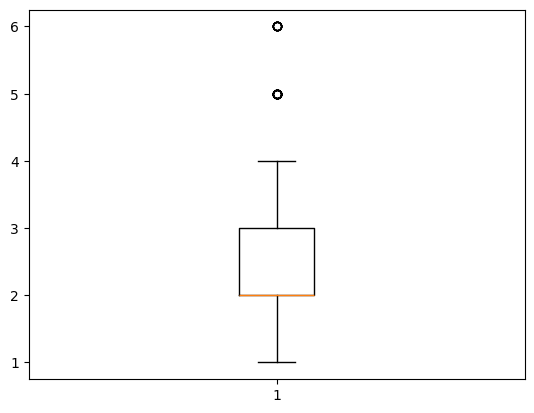

In [ ]:
plt.boxplot(df['BHK'])
plt.show()

In [ ]:
def remove_outliers_iqr(data, column_name="value"):

    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column_name] >= lower) & (df[column_name] <= upper)]
cleaned_df = remove_outliers_iqr(df, column_name="BHK")

print(df.shape,cleaned_df.shape)

(4721, 21) (4694, 21)


In [ ]:
X=df.drop(['Rent'],axis=1)
y=df['Rent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                   test_size= 0.20, random_state=100, stratify=None)

print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (3776, 20)  y_train =  (3776,)
X_test  =  (945, 20)  y_test  =  (945,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
my_scaler = MinMaxScaler(feature_range=(0,1))
X_train[['Size']] = my_scaler.fit_transform(X_train[['Size']]) # X_train
X_test[['Size']] = my_scaler.transform(X_test[['Size']]) # X_test

In [ ]:
X_train['Size'].min(),X_train['Size'].max()

(0.0, 1.0)

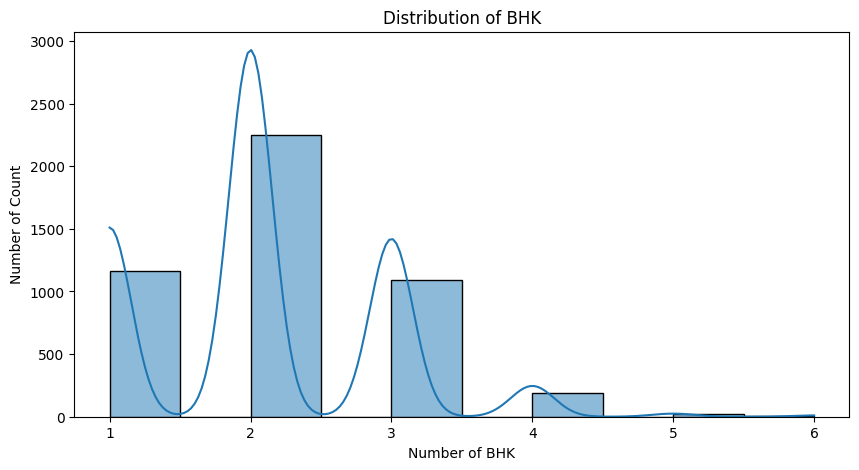

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.histplot(df['BHK'], bins=10, kde=True)
plt.title("Distribution of BHK")
plt.xlabel('Number of BHK')
plt.ylabel('Number of Count')
plt.show()

In [ ]:
from tqdm import tqdm
!pip install xgboost lightgbm catboost

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression , Lasso ,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import (RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,
                              AdaBoostRegressor ,GradientBoostingRegressor,HistGradientBoostingRegressor
                              , VotingRegressor,StackingRegressor)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [ ]:
def regression_metrics(model, X, y_actual):
    y_pred = model.predict(X)
    MAE = mean_absolute_error(y_actual, y_pred)
    MSE = mean_squared_error(y_actual, y_pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(y_actual, y_pred)
    return MAE, MSE, RMSE, R2

In [ ]:
models ={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "KNN":KNeighborsRegressor(n_neighbors=5,metric='minkowski',p=1), #  minkowski , euclidean , manhattan
    #"SVM":SVR(kernel='linear', C=100, gamma=1), # kernel='rbf' / kernel='poly', degree=4 / kernel='sigmoid
    "Decision Tree":DecisionTreeRegressor(criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "Random Forest":RandomForestRegressor(n_estimators=50,criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Bagging": BaggingRegressor(estimator=DecisionTreeRegressor(criterion='squared_error',max_depth=10),n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=15, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0, iterations=100, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

  0%|          | 0/14 [00:00<?, ?it/s]

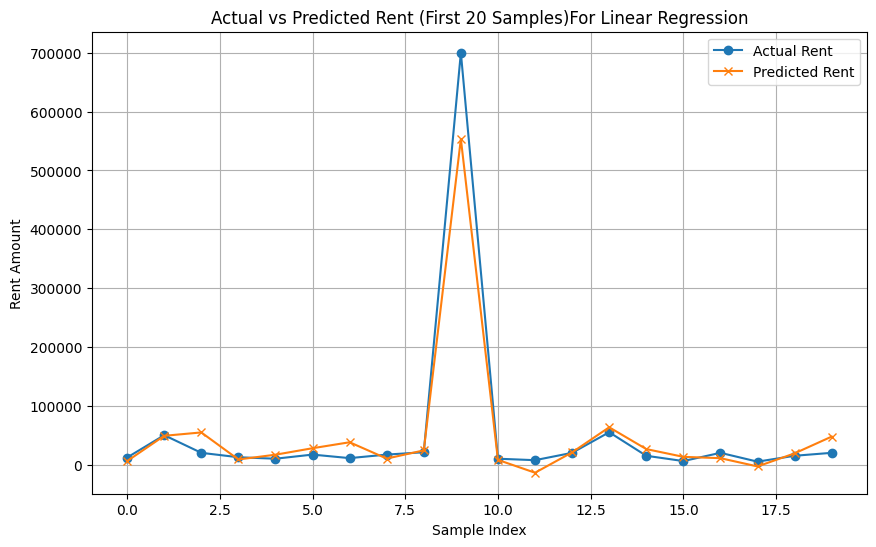

  7%|▋         | 1/14 [00:00<00:04,  3.20it/s]

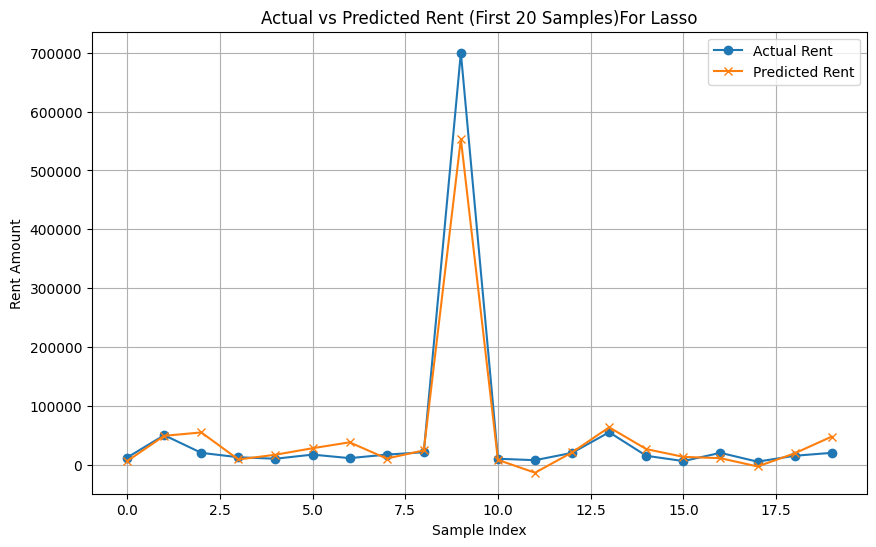

 14%|█▍        | 2/14 [00:00<00:03,  3.68it/s]

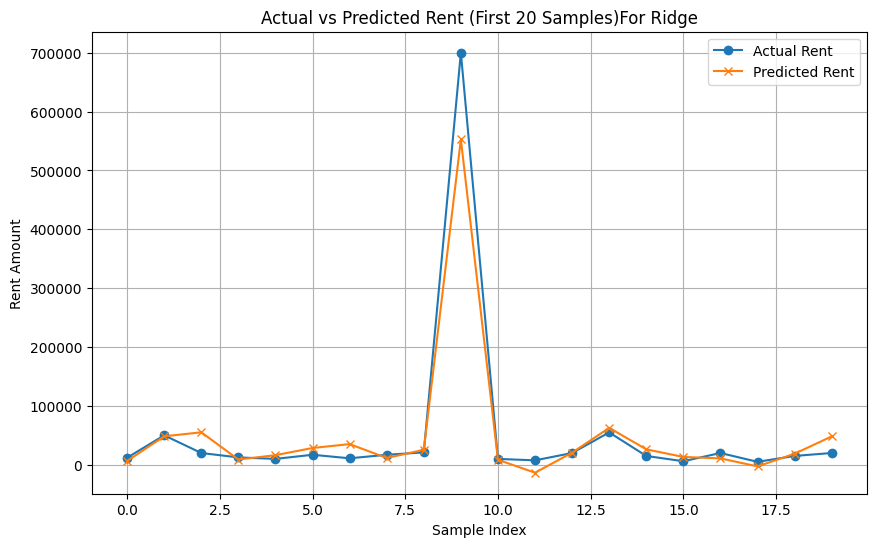

 21%|██▏       | 3/14 [00:00<00:03,  3.23it/s]

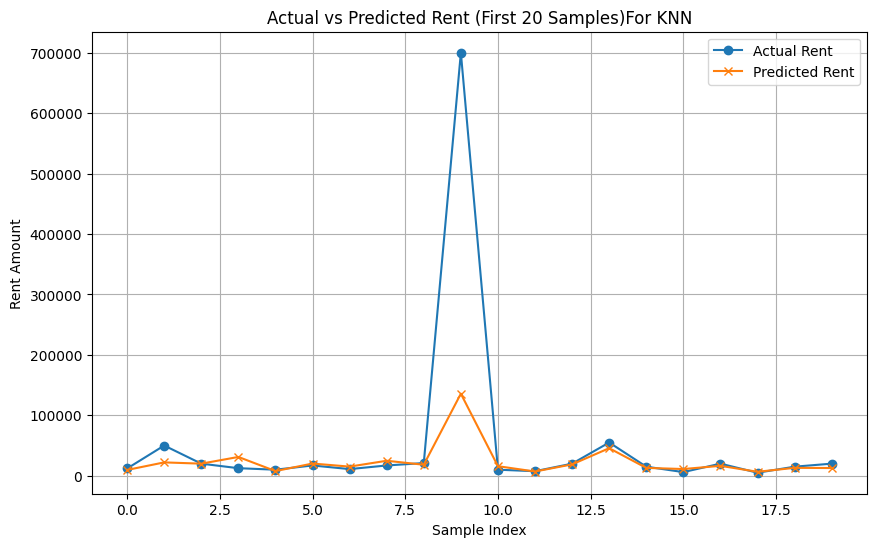

 29%|██▊       | 4/14 [00:01<00:04,  2.21it/s]

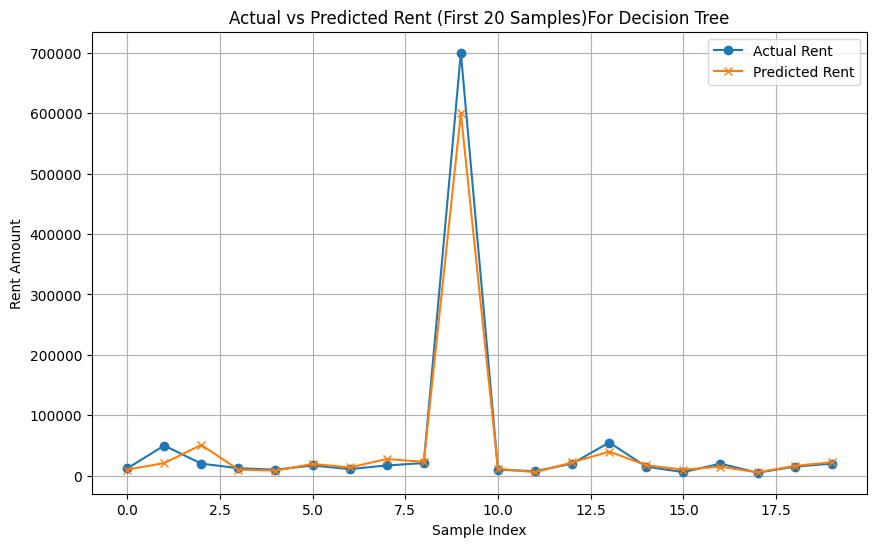

 36%|███▌      | 5/14 [00:01<00:03,  2.50it/s]

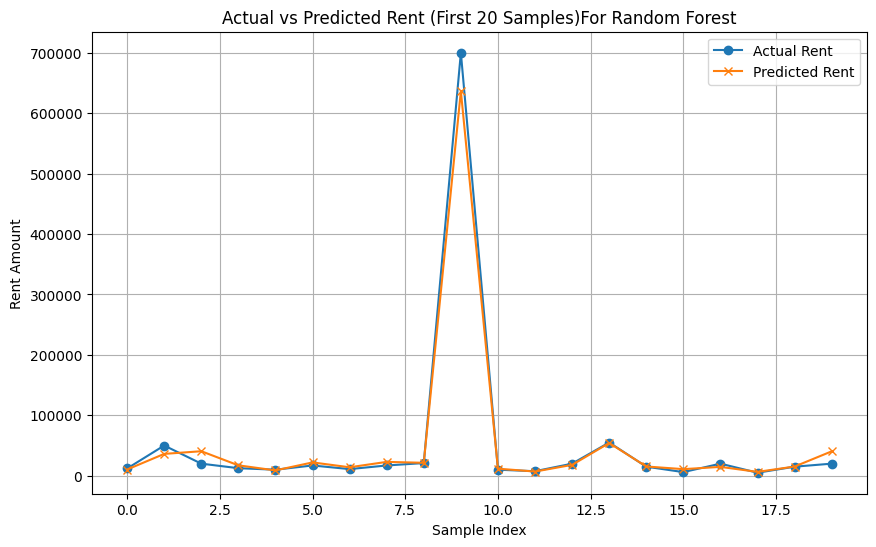

 43%|████▎     | 6/14 [00:03<00:05,  1.55it/s]

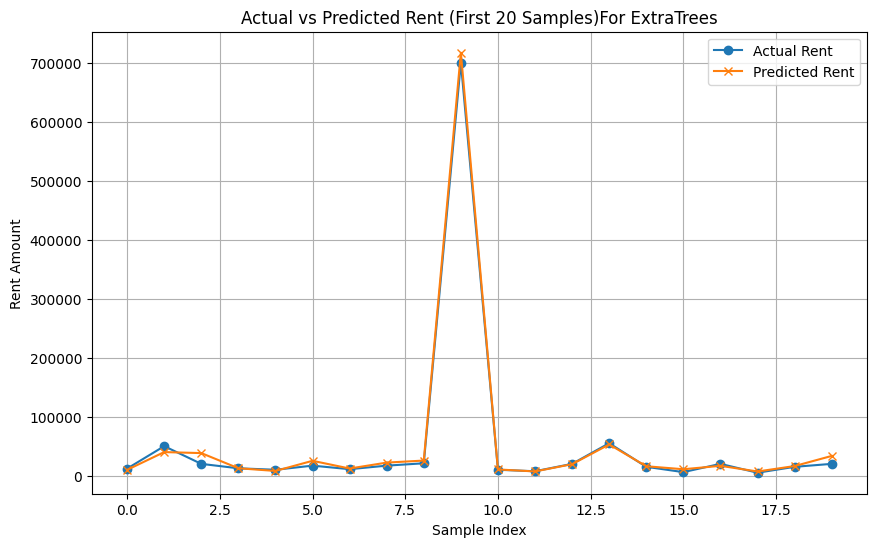

 50%|█████     | 7/14 [00:06<00:12,  1.73s/it]

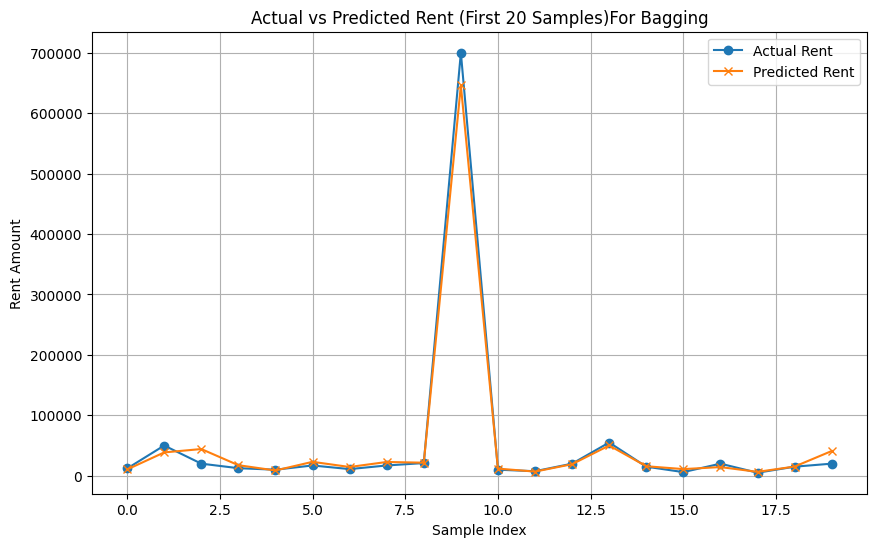

 57%|█████▋    | 8/14 [00:09<00:11,  1.99s/it]

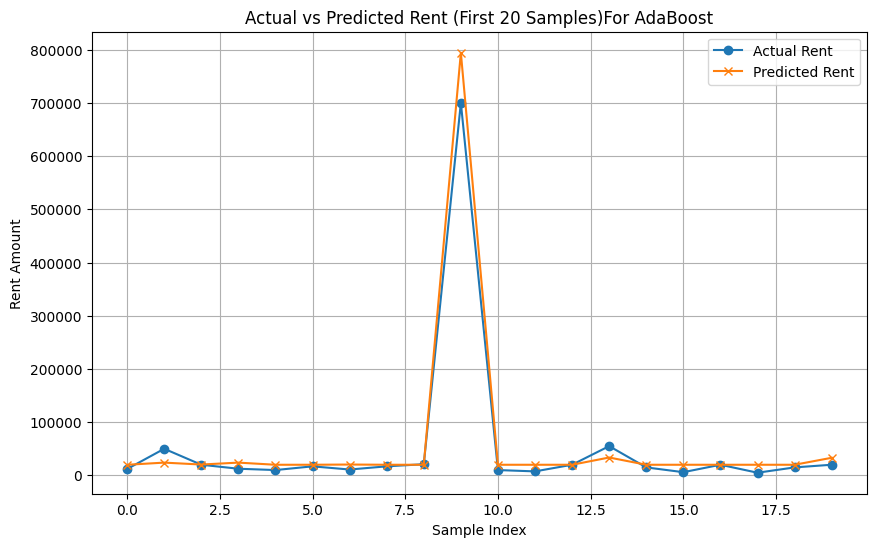

 64%|██████▍   | 9/14 [00:10<00:08,  1.70s/it]

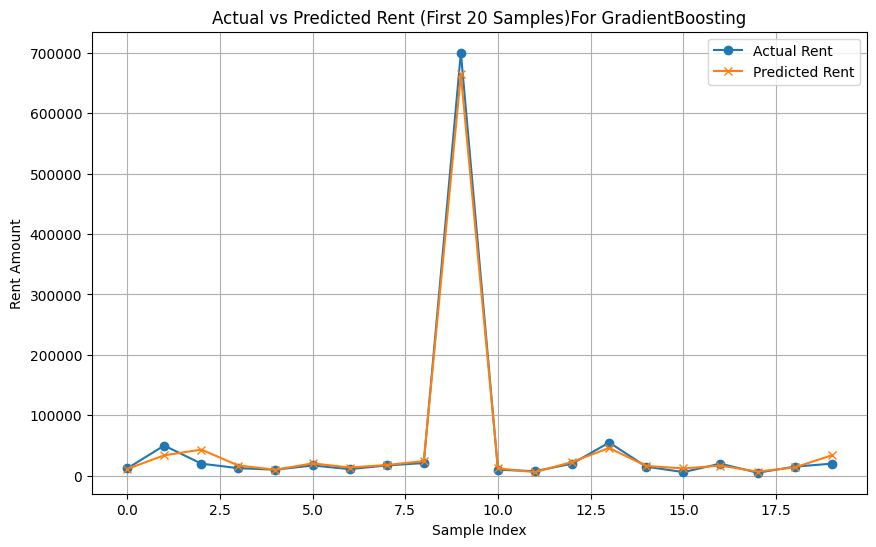

 71%|███████▏  | 10/14 [00:13<00:08,  2.08s/it]

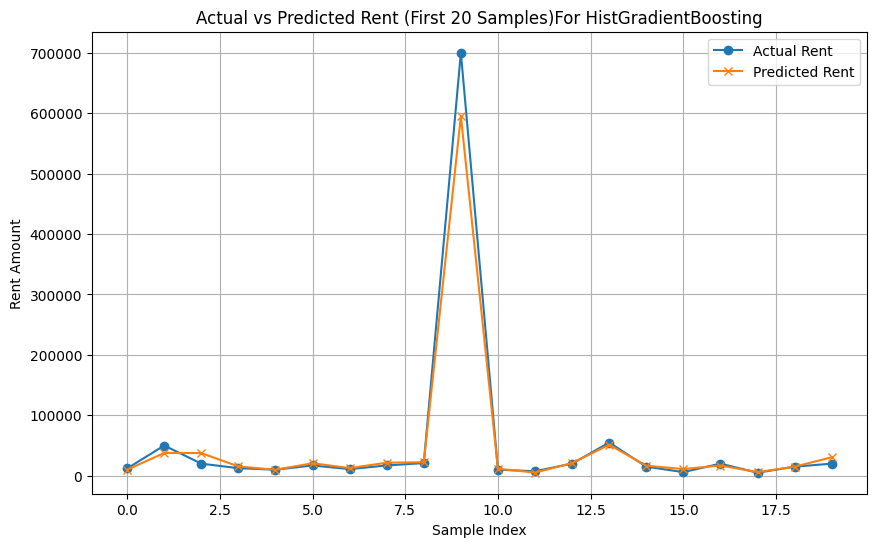

 79%|███████▊  | 11/14 [00:15<00:06,  2.13s/it]

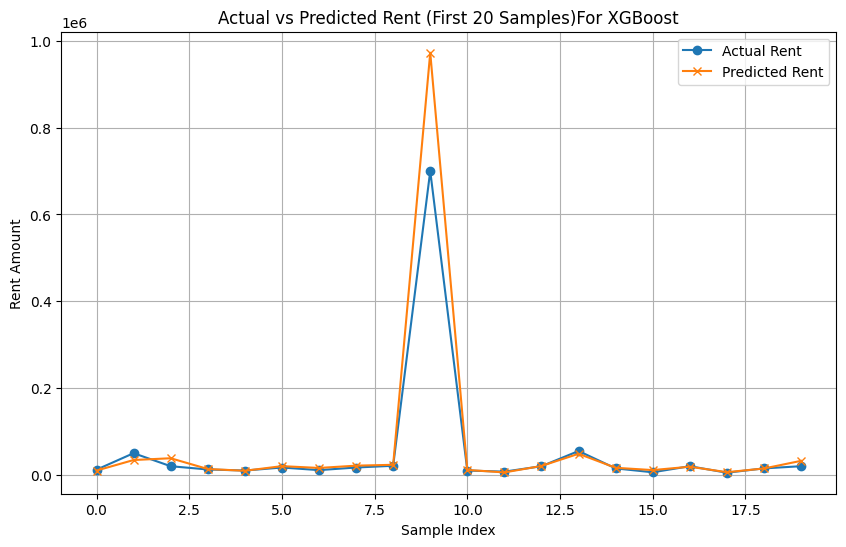

 86%|████████▌ | 12/14 [00:17<00:04,  2.13s/it]

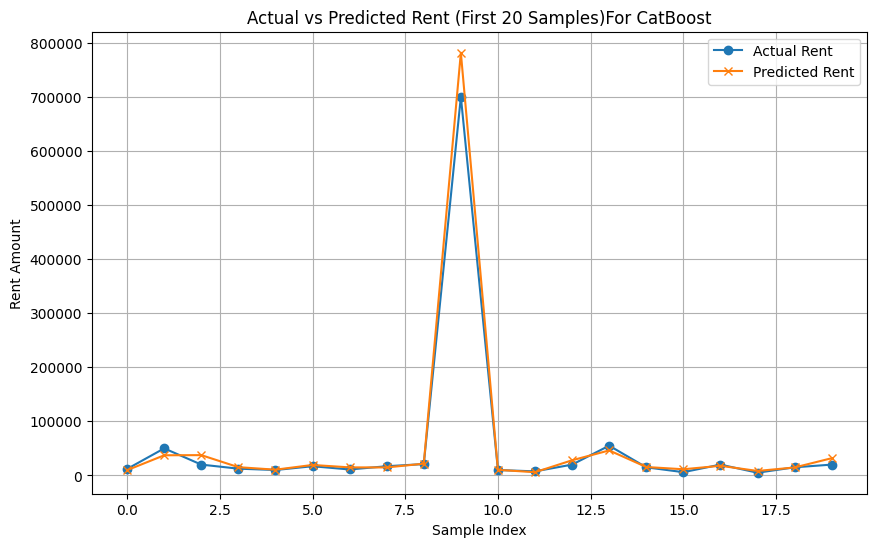

 93%|█████████▎| 13/14 [00:19<00:01,  1.95s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 649
[LightGBM] [Info] Number of data points in the train set: 3776, number of used features: 18
[LightGBM] [Info] Start training from score 33606.182733


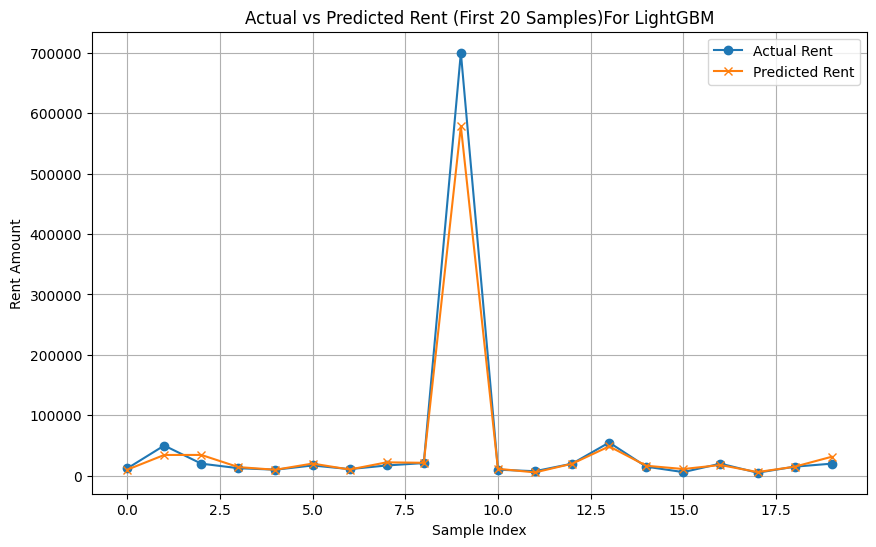

100%|██████████| 14/14 [00:20<00:00,  1.44s/it]


In [ ]:
errors={}
for model_name , model in tqdm(models.items()):
    model.fit(X_train,y_train)
    MAE_Train, MSE_Train, RMSE_Train, R_Train = regression_metrics(model, X_train, y_train)
    MAE_Test, MSE_Test, RMSE_Test, R_Test = regression_metrics(model, X_test, y_test)

    errors[model_name] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R_Train,
        "R2 Test":R_Test
    }


    y_test_plot = y_test.values[:20]
    y_pred_plot = model.predict(X_test[:20])

    plt.figure(figsize=(10,6))
    plt.plot(range(20), y_test_plot, label='Actual Rent', marker='o')
    plt.plot(range(20), y_pred_plot, label='Predicted Rent', marker='x')
    plt.xlabel('Sample Index')
    plt.ylabel('Rent Amount')
    plt.title('Actual vs Predicted Rent (First 20 Samples)For '+ model_name)
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
errors_df = pd.DataFrame(errors).T.sort_values(by="R2 Test",ascending=False)

In [ ]:
errors_df

,MAE Train,MAE Test,MSE Train,MSE Test,RMSE Train,RMSE Test,R2 Train,R2 Test
Decision Tree,3246.971604,12525.870957,3.497651e+07,9.710598e+09,5914.093853,98542.368399,0.990221,0.402636
Ridge,11934.217303,15777.707842,9.095902e+08,1.006265e+10,30159.412415,100312.744365,0.745689,0.380979
Lasso,12093.639968,15928.538551,9.090055e+08,1.006942e+10,30149.717649,100346.499920,0.745853,0.380562
Linear Regression,12098.259904,15939.448713,9.089973e+08,1.007005e+10,30149.582866,100349.651108,0.745855,0.380523
Bagging,4127.725224,11671.230132,1.191023e+08,1.067515e+10,10913.397838,103320.626632,0.966700,0.343300
Random Forest,4106.970802,11773.104583,1.244192e+08,1.072560e+10,11154.337132,103564.492973,0.965214,0.340196
HistGradientBoosting,5435.830025,11712.938852,3.672561e+08,1.106519e+10,19163.925755,105191.204809,0.897320,0.319306
LightGBM,5310.485783,11906.600152,3.658681e+08,1.135479e+10,19127.678289,106558.859007,0.897708,0.301490
GradientBoosting,5906.514543,12733.577658,1.483774e+08,1.150828e+10,12181.026928,107276.646946,0.958515,0.292048
ExtraTrees,3.127648,10755.185153,2.948835e+03,1.174918e+10,54.303174,108393.640411,0.999999,0.277229
